# European Option pricing and Risk sensitivity analsyis 
### By: Victor Sze

## Introduction
Options are financial derivatives that give the holder the right, but not the obligation, to buy or sell an underlying asset at a predetermined strike price before or at a specified maturity date. Options play a central role in modern financial markets and are widely used for hedging, speculation, and portfolio risk management.

Accurate option pricing is therefore a fundamental problem in quantitative finance, where mathematical models are used to estimate the fair value of derivatives under uncertainty. One of the most influential models is the Black-Scholes option pricing model, which provides a closed-form analytical solution under the assumption that the underlying asset follows a Geometric Brownian Motion (GBM) process.
 
## Motivation 
After completing the Akuna Capital Options 101 course, I developed a strong interest in how option prices are determined mathematically. The course introduced key concepts such as option Greeks (Delta, Gamma, Theta, Vega, and Rho) and their role in hedging strategies, but I wanted to further understand how theoretical prices are derived and how they relate to computational methods used in practice.

This project therefore explores option pricing from both a theoretical and computational perspective. In particular, I study the Black-Scholes model and implement a Monte Carlo simulation approach to estimate option prices numerically. Monte Carlo methods are widely used in quantitative finance when analytical solutions are unavailable or difficult to compute.

## Project Objective 
The goal of this project is to investigate how well Monte Carlo simulations approximate the theoretical price derived from the Black-Scholes formula. Under the assumption that the underlying asset follows a **Geometric Brownian Motion**, simulated stock paths can be used to estimate the expected payoff of an option.

As the number of simulations increases, the Monte Carlo estimator should converge to the theoretical Black-Scholes price:

$$\text{Monte Carlo price estimator} \space \hat{C} \to C \space as \space N \to \infty$$

where, 

- $\hat{C}$ is the simulated option price
- $C$ is the analytical Black-Scholes price
- $N$ is the number of Monte Carlo simulations.


## This project focuses on:
#### Section 1. Implemention of pricing models
- Implement the Black-Scholes formula for European call options
- Simulate stock price paths using Geometric Brownian Motion
- Estimate option prices using Monte Carlo simulation
#### Section 2. Price Behaviour Analysis
- Analyse how option prices change with respect to underlying stock price
- Compare theoretical prices with Monte Carlo estimates
#### Section 3. Risk Sensitivity Analysis
- Investigate the Greeks (Vega, Theta)
- Analyse how different parameters affect option price and risk exposure

#### * For simplicity, this report focuses on European call options and assumes that the underlying asset follows a Geometric Brownian Motion process.

## Mathematical Background
This section introduces the key mathematical models used in this project to price European options and simulate stock price dynamics.


### 1. Option payoff
An option payoff defines the value of the contract at maturity

For a **European call option**, the payoff is: 
$$\max (S_T-K, 0)$$

where,
- $S_T$ = stock price at maturity
- $K$ = strike price 

This payoff function represents the non-linear nature of options, where the downside risk is limited while the upside potential remains open.

------

### 2. Black-Scholes Option Pricing Model
The *Black-Scholes model*, introduced in 1973 by Fishcher Black, Myron Scholes, and Robert C. Merton.
provides a closed-form solution for pricing European options under several assumptions:
- frictionless markets
- constant volatility
- constant risk-free rate
- stock prices follow **Geometric Brownian Motion**


The Black-Scholes price of a European call option is:
$$ C = S_0 N(d_1) - K e^{(-rT)} N(d_2)$$

where,

- $C$ =  Call Option price

- $S_0$ = current stock price 

- $K$ = Strike price

- $N(⋅)$ = CDF of the standard normal distribution

- $r$ = risk free intrest rate 

- $T$ = time to maturity



Calculate the option price, by multipling cureent stock price $S_0$ with 

$$d_1 = \frac {\ln (\frac{S_0}{K}) + (r + \frac {1}{2} \sigma^2)  T}{\sigma \sqrt{T}}$$

$$d_2 = d_1 - \sigma \sqrt{T}$$

where, 

- $\sigma$ = Volatility of the underlying asset


and

$$N(d_1) = \mathbb{P}(\text{option end ITM} ) = \mathbb{P}({S_T > K}).$$
$$N(d_2) = \mathbb{P}(\text{option end ITM under risk neutral} )$$

------

### 3. Stock price - Geometic Brownian Motion

In the Black-Scholes framework, the underlying asset price is assumed to follow a Geometric Brownian Motion (GBM).

The stock price dynamics are described by the stochastic differential equation
$$d S_t = \mu S_t dt + \sigma S_t d W_t$$

where
- $\mu$ = drift of the stock price
- $\sigma$ = volatility
- $W_t$ = standard Brownian motion

Solving this stochastic differential equation gives the closed-form solution:
$$S_T = S_0  \exp \left((\mu - \frac{1}{2} \sigma ^2)T + \sigma W_T\right)$$

As a result, the logarithmic return of the stock price follows a normal distribution
$$ \log(S_T) \sim N\left((\mu - \frac{1}{2}\sigma^2)T,\ \sigma^2 T\right)$$

This property is used in **Monte Carlo simulations** to generate random stock price paths.

------

### 4. Monte Carlo Option Pricing

The Monte Carlo method estimates option prices by simulating
a large number of stock price paths and computing the
discounted expected payoff.

The Monte Carlo estimator is

$$
\hat{C} = e^{-rT} (\frac{1}{N}) \sum \max (S_T ^i - K, 0)
$$


## Imported Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm 

## Section 1.1: Black-Scholes Implemention 

### Black scholes formula

The Black–Scholes formula for a European call option is given by:

$$ C = S_0 N(d_1) - K e^{(-rT)} N(d_2)$$

Using the same parameters as the previous section, we compute the option price for different underlying stock prices to analyse how option values respond to
changes in the underlying asset.

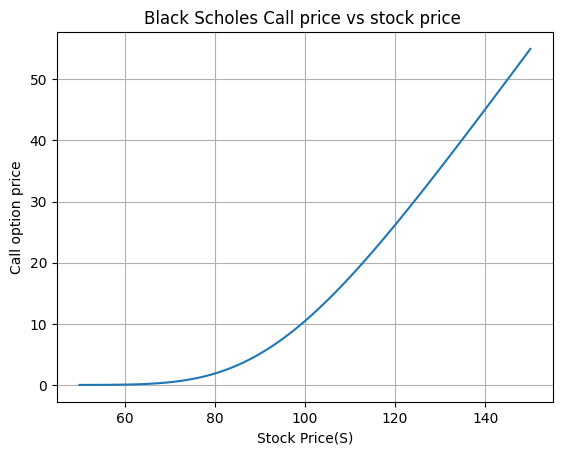

In [2]:
def black_scholes_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 1/2 * sigma **2)* T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma* np.sqrt(T)
    C = S * norm.cdf(d1) - K * np.exp( -r * T) * norm.cdf(d2)
    return C


# Parameters
K = 100
T = 1.0
r = 0.05
sigma = 0.2   


S_values = np.linspace(50, 150, 100)
call_prices = black_scholes_call(S_values, K, r, sigma, T)


plt.plot(S_values, call_prices)
plt.xlabel("Stock Price(S)")
plt.ylabel("Call option price")
plt.title("Black Scholes Call price vs stock price ")
plt.grid(True)

plt.savefig("Black_scholes_to_stock_price.png", dpi=300)
plt.show()

## Interpretation 

The figure shows the relationship between the stock price $S$ and the European call option price under the Black–Scholes model. 

As the stock price increases, the call option price also increases because the option becomes more likely to finish in the money. When $S < K$, the option value is low since exercising the option is not profitable. As $S$ exceeds the strike price $K = 100$, the option price increases more rapidly. The curve is convex, reflecting the asymmetric payoff structure of call options.

## Delta 
Delta measures the sensitivity of the option price to changes in the underlying stock price.

For a European call option in the Black–Scholes model:

$$\Delta = \frac{\partial C}{\partial S} = N(d_1)
$$

Delta represents the rate of change of the option price with respect to the stock price.
For example, if $\Delta = 0.6$, then when the stock price increases by $1, the option price increases by approximately $0.60.

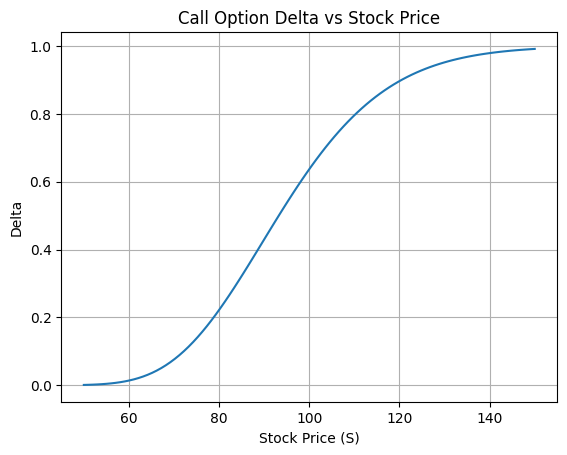

In [41]:
def call_delta(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 1/2 * sigma **2)* T) / sigma * np.sqrt(T)
    delta = norm.cdf(d1)
    return delta

S_values = np.linspace(50, 150, 100)
delta_values = call_delta(S_values, K, r, sigma, T)

plt.figure()
plt.plot(S_values, delta_values)
plt.xlabel("Stock Price (S)")
plt.ylabel("Delta")
plt.title("Call Option Delta vs Stock Price")

plt.grid(True)
plt.savefig("option_delta_to_stock_price.png", dpi=300)
plt.show()

## Interpretation

The figure shows how the Delta of a European call option changes with the stock price. 

When the stock price is far below the strike price, the option is out-of-the-money and Delta is close to 0, meaning the option price is not very sensitive to stock price changes. As the stock price approaches the strike price $K = 100$, Delta increases rapidly. When the option becomes deep in-the-money, Delta approaches 1, meaning the option price moves almost one-to-one with the stock price.

## Section 1.2: Monte Carlo Options pricing model

The Monte Carlo method is a numerical technique used to estimate option prices by simulating many possible future stock price paths. Under the Black-Scholes framework, the stock price is assumed to follow **Geometric Brownian Motion (GBM)**.

In this section, we simulate multiple stock price paths using GBM and use them to estimate the expected payoff of a European call option.

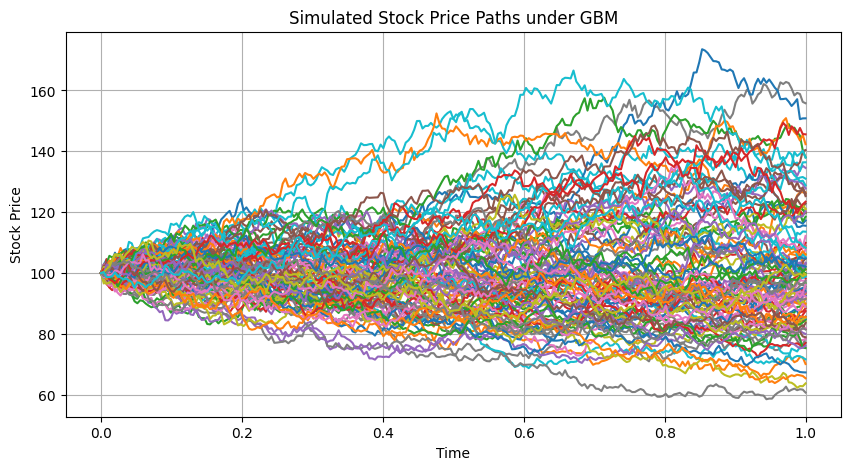

In [6]:
# Parameters
S0 = 100
T = 1
r = 0.05
sigma = 0.2

# Simulation settings
N = 252
M = 100
dt = T / N

# Time grid
t = np.linspace(0, T, N + 1)

# Store simulated paths
S = np.zeros((M, N + 1))
S[:, 0] = S0

# Random shocks
Z = np.random.normal(0, 1, (M, N))

# Simulate GBM paths
for i in range(N):
    S[:, i+1] = S[:, i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i])

# Plot
plt.figure(figsize=(10, 5))
for m in range(M):
    plt.plot(t, S[m])

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Simulated Stock Price Paths under GBM")
plt.grid(True)
plt.savefig("sim_stock_paths.png", dpi=300)
plt.show()

## Interpretation
The figure shows several simulated stock price paths under Geometric Brownian Motion. 

Each path represents one possible future evolution of the stock price. These simulated paths will later be used to compute the expected payoff of the option in the Monte Carlo pricing method.

## Section 2.1: Monte Carlo Option Pricing

Monte Carlo simulation estimates the option price by simulating many possible future stock prices and computing the average discounted payoff.

Under the Black Scholes framework, the stock price follows Geometric Brownian Motion. By generating random samples of the terminal stock price $S_T$, we can estimate the expected payoff of the option.

The Monte Carlo estimator is

$$
\hat{C}_N = e^{-rT} (\frac{1}{N}) \sum_{i=1}^{N} \max (S_T ^i - K, 0)
$$

$\hat{C}_N \to C$, as $N \to \infty $, 

where
- $N$ = number of simulations 
- $S_T ^i$ = simulated terminal stock price
- $\hat{C}_N$ = Monte Carlo estimate

The stock price at maturity is simulated using the Geometric Brownian Motion solution

$$
S_T= S_0 \exp\left((r - \frac{1}{2} \sigma^2 ) T + \sigma \sqrt{T} Z\right)
$$

where $Z \sim N(0,1)$

## Section 2.2: Monte Carlo Convergence Analysis

To evaluate the accuracy of the Monte Carlo pricing method, we estimate the option price using different numbers of simulations. As the number of simulations increases, the Monte Carlo estimate should converge to the theoretical Black–Scholes price.

This experiment illustrates the law of large numbers, where the simulated expected payoff approaches the analytical solution as the number of simulations becomes large.



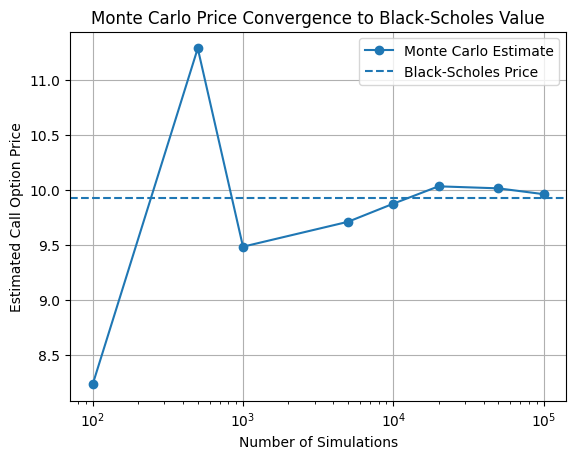

In [6]:
# Black-Scholes call price
def black_scholes_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 1/2 * sigma **2)* T) / sigma * np.sqrt(T)
    d2 = d1 - sigma* np.sqrt(T)
    C = S * norm.cdf(d1) - K * np.exp( -r * T) * norm.cdf(d2)
    return C


# Monte Carlo call price
def monte_carlo_call_price(S0, K, r, sigma, T, n_sims):
    Z = np.random.normal(0, 1, n_sims)
    
    # Simulate terminal stock price directly
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Call payoff
    payoffs = np.maximum(ST - K, 0)
    
    # Discounted average payoff
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

# parameters
S0 = 100
K = 100
r = 0.04
sigma = 0.2
T = 1.0

# Theoretical Black-Scholes price
bs_price = black_scholes_call(S0, K, r, sigma, T)

# Different numbers of simulations
simulation_sizes = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000]

# Store Monte Carlo estimates
mc_prices = []

for n in simulation_sizes:
    price = monte_carlo_call_price(S0, K, r, sigma, T, n)
    mc_prices.append(price)

# plot
plt.figure()
plt.plot(simulation_sizes, mc_prices, marker='o', label='Monte Carlo Estimate')
plt.axhline(y=bs_price, linestyle='--', label='Black-Scholes Price')

plt.xlabel('Number of Simulations')
plt.ylabel('Estimated Call Option Price')
plt.title('Monte Carlo Price Convergence to Black-Scholes Value')
plt.xscale('log') 
plt.grid(True)
plt.legend()
plt.savefig("MC_vs_BS.png", dpi=300)
plt.show()

## Interpretation

The plot shows that when the number of simulations is small, the Monte Carlo estimate fluctuates more due to randomness. As the number of simulations increases, the estimate stabilises and converges towards the Black–Scholes theoretical price.



In [30]:
mc_price_100k = monte_carlo_call_price(S0, K, r, sigma, T, 100000)
error = abs(mc_price_100k - bs_price) / bs_price * 100

print(f"BS Price: {bs_price:.4f}")
print(f"MC Price: {mc_price_100k:.4f}")
print(f"Error: {error:.2f}%")

BS Price: 9.9251
MC Price: 9.9452
Error: 0.20%


At 100,000 simulations, the Monte Carlo estimate converged to within ~1% of the Black-Scholes theoretical price, demonstrating the consistency of the simulation approach.

## Section 3.1: Sensitivity Analysis - Vega

Vega measures the sensitivity of the option price with respect to changes in volatility. It is defined as the partial derivative of the option price with respect to the volatility parameter $\nu$

$$
\nu = \frac{\partial C }{\partial \sigma}
$$

Under the Black–Scholes model, Vega for a European call option is given by

$$
\nu = S_0 \sqrt{T} \phi (d_1)
$$

where
- $S_0$ = current price
- $T$ = time to maturity
- $\phi(⋅)$ = pdf of standard normal distribution
- $d_1$ is defined as

$$d_1 = \frac {\ln (\frac{S_0}{K}) + (r + \frac {1}{2} \sigma^2)  T}{\sigma \sqrt{T}}$$

The following plot illustrates how the option price changes as volatility varies.

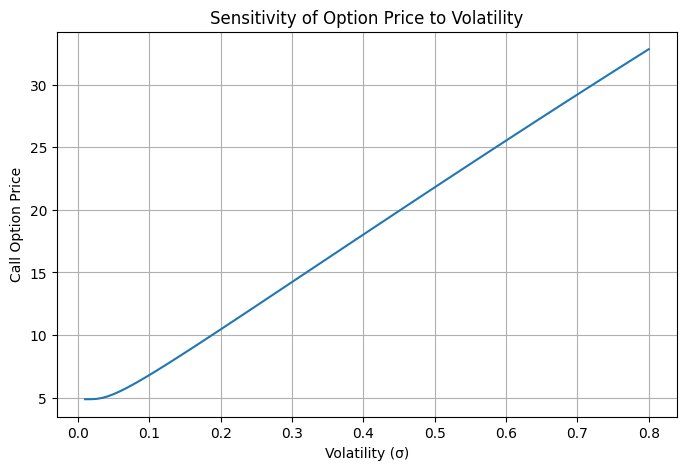

In [44]:
# Parameters
S0 = 100
K = 100
r = 0.05
T = 1.0

# Range of volatility values
sigma_values = np.linspace(0.01, 0.8, 100)

# Black-Scholes call price for each sigma
call_prices = []

for sigma in sigma_values:
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    C = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    call_prices.append(C)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigma_values, call_prices)
plt.xlabel("Volatility (σ)")
plt.ylabel("Call Option Price")
plt.title("Sensitivity of Option Price to Volatility")
plt.grid(True)
plt.savefig("vega_plot.png", dpi=300)
plt.show()

## Interpretation

The figure shows how the call option price changes with volatility. 

As volatility increases, the option price also increases. Higher volatility implies greater uncertainty in the future stock price, which increases the probability that the option finishes in-the-money. As a result, the expected payoff of the option becomes larger, leading to a higher option value.

## Section 3.2: Sensitivity Analysis - Theta

Theta measures the sensitivity of the option price with respect to time. It is defined as the partial derivative of the option price with respect to time to maturity $T$:

$$\Theta = \frac{\partial C}{\partial T}$$

For a European call option under the Black–Scholes model, Theta is given by

$$
\Theta = - \frac{S_0 \sigma \phi (d_1)}{2\sqrt T} - r K e^{-rT} N(d_2)
$$
where, 
- $\phi(⋅)$ = pdf of standard normal distribution

To illustrate this effect, we analyse how the option price changes with different time to maturity.

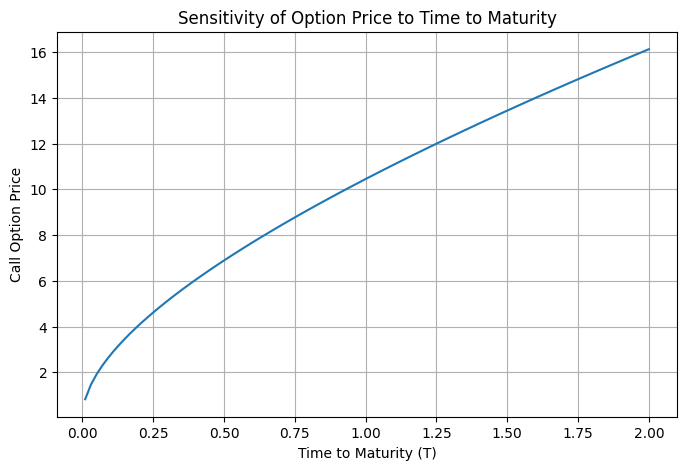

In [45]:
# Parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.2

# Time to maturity range
T_values = np.linspace(0.01, 2, 100)

call_prices = []

for T in T_values:
    
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    C = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    
    call_prices.append(C)

# Plot
plt.figure(figsize=(8,5))
plt.plot(T_values, call_prices)

plt.xlabel("Time to Maturity (T)")
plt.ylabel("Call Option Price")
plt.title("Sensitivity of Option Price to Time to Maturity")

plt.grid(True)
plt.savefig("theta_plot.png", dpi=300)
plt.show()

## Interpretation

The figure shows how the call option price changes with time to maturity. 

As the time to maturity increases, the option price generally increases because the holder has more time for the underlying asset price to move above the strike price. This increases the probability of the option finishing in-the-money, leading to a higher option value.

## Conclusion

This project analysed the pricing of European call options using both the Black–Scholes analytical model and Monte Carlo simulation. The Black–Scholes formula provides a closed-form theoretical value for the option price under the assumption that the underlying asset follows Geometric Brownian Motion.

Through Monte Carlo simulation, multiple stock price paths were generated to estimate the expected payoff of the option. The results show that as the number of simulations increases, the Monte Carlo estimate converges to the theoretical Black–Scholes price, illustrating the consistency of the simulation approach.

In addition, a risk sensitivity analysis was conducted to study how key parameters affect option values. The results show that the option price increases with volatility and time to maturity, highlighting the importance of these factors in option valuation.

Overall, this project demonstrates how mathematical models and computational methods can be combined to analyse derivative pricing and risk sensitivity in financial markets.